## Training multi-fidelity neural networks for small/large amplitude oscillatory shear (S/LAOS) rheometry
The output of this notebook is the model's stored training, which is used to predict the oscillatory shear stress.

### Importing the dependencies

In [11]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [12]:
from time import time
from datetime import datetime
import os
import sys
import math
import tensorflow as tf
import numpy as np
import scipy.optimize
import pandas as pd
import matplotlib.pyplot as plt
from numpy import random
import itertools

# Standard library
import os
import sys
from time import time

# Numerical / scientific computing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import odeint

# Scikit-learn core utilities
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.compose import TransformedTargetRegressor

# Scikit-learn models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor, RegressorChain

# Gaussian Processes
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

# XGBoost
import xgboost as xgb


### Loading the Lo-Fi and Hi-Fi data
We generated the Lo-Fi data using a Maxwell model with inputs being the time, maximum strain, and angular frequency. However, and as stated in the manuscript, the same set of inputs fails to yield accurate stress predictions for MFNN training. Therefore, the inputs here are the strain, strain rate, and angular frequency, with the output being the shear stress.

If the input data is noisy, one can use the `moving_average_filter()` function below to smoothen the data.

In [13]:
DTYPE='float32'
tf.keras.backend.set_floatx(DTYPE)
SEED=8
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

log10 = tf.experimental.numpy.log10
path = os.getcwd()
files = os.listdir(path)
df = {}
Shuffle = False

url_hf_raw = r"/home/alanh/projects/PunLab/mfnn/experiments/Pigs_NegCon/combined_pig_negcon.xlsx"
url_lf, url_hf = r"/home/alanh/projects/PunLab/mfnn/notebooks/Data_LF_SAOS.xlsx", r"/home/alanh/projects/PunLab/mfnn/notebooks/Data_HF_SAOS.xlsx"

df_LF = pd.read_excel(url_lf, sheet_name=None)
data_LF = [[k,v] for k,v in df_LF.items()] #k is the sheet name, v is the pandas df

df_HF = pd.read_excel(url_hf, sheet_name=None)
data_HF = [[k,v] for k,v in df_HF.items()] 

# Helper function to concatenate all sheets
def load_and_concat_sheets(data_list):
    frames = []
    for sheet_name, df in data_list:
        # Drop NaNs just like before
        df = df.dropna()
        # Optional: Subsample if data is too large (currently commented out)
        # df = df.iloc[::20] 
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

# 1. Process Lo-Fi Data (All Sheets)
df_LF_concat = load_and_concat_sheets(data_LF)

x1_d_LF = tf.reshape(tf.convert_to_tensor(df_LF_concat['Strain'], dtype=DTYPE),(-1,1))
x2_d_LF = tf.reshape(tf.convert_to_tensor(df_LF_concat['StrainRate'], dtype=DTYPE), (-1,1))
x3_d_LF = tf.reshape(tf.convert_to_tensor(df_LF_concat['AngFreq'], dtype=DTYPE), (-1,1))
x4_d_LF = tf.reshape(tf.convert_to_tensor(df_LF_concat['Time'], dtype=DTYPE), (-1,1))
x5_d_LF = tf.reshape(tf.convert_to_tensor(df_LF_concat['G0'], dtype=DTYPE), (-1,1))
y1_d_LF = tf.reshape(tf.convert_to_tensor(df_LF_concat['Stress'], dtype=DTYPE), (-1,1))

# 2. Process Hi-Fi Data (All Sheets)
df_HF_concat = load_and_concat_sheets(data_HF)

x1_d_HF = tf.reshape(tf.convert_to_tensor(df_HF_concat['Strain'], dtype=DTYPE),(-1,1))
x2_d_HF = tf.reshape(tf.convert_to_tensor(df_HF_concat['StrainRate'], dtype=DTYPE), (-1,1))
x3_d_HF = tf.reshape(tf.convert_to_tensor(df_HF_concat['AngFreq'], dtype=DTYPE), (-1,1))
x4_d_HF = tf.reshape(tf.convert_to_tensor(df_HF_concat['Time'], dtype=DTYPE), (-1,1))
x5_d_HF = tf.reshape(tf.convert_to_tensor(df_HF_concat['G0'], dtype=DTYPE), (-1,1))
y1_d_HF = tf.reshape(tf.convert_to_tensor(df_HF_concat['Stress'], dtype=DTYPE), (-1,1))

# Moving Average Filter (applied to the concatenated HF data)
def moving_average_filter(data, window_size):
    window = np.ones(window_size) / window_size
    smoothed_data = np.convolve(data, window, mode='same')
    return smoothed_data

# window_size = 2
# y1_d_HF = moving_average_filter(np.reshape(y1_d_HF, (-1,)), window_size)
# y1_d_HF = tf.reshape(tf.convert_to_tensor(y1_d_HF, dtype=DTYPE), (-1,1))

# Calculate bounds based on the full dataset
x1min, x1max = np.min(x1_d_HF), np.max(x1_d_HF)
x2min, x2max = np.min(x2_d_HF), np.max(x2_d_HF)
x3min, x3max = np.min(x3_d_HF), np.max(x3_d_HF)

# lb = tf.constant([x1min, x2min, x3min], dtype=DTYPE).numpy()
# ub = tf.constant([x1max, x2max, x3max], dtype=DTYPE).numpy()

# LF: Add x5_d_LF (G0) to inputs
X_data_LF = tf.concat([x1_d_LF, x2_d_LF, x3_d_LF, x5_d_LF], axis=1)
y_data_LF = tf.concat([y1_d_LF], axis=1)  

# HF: Add x5_d_HF (G0) to inputs
X_data_HF = tf.concat([x1_d_HF, x2_d_HF, x3_d_HF, x5_d_HF], axis=1)
y_data_HF = tf.concat([y1_d_HF], axis=1)  

# Update input dimension
in_dim, out_dim = 4, 1

if Shuffle:
    X_data_HF = X_data_HF.numpy()
    X_data_LF = X_data_LF.numpy()
    y_data_HF = y_data_HF.numpy()
    y_data_LF = y_data_LF.numpy()

    # Get the number of samples
    num_samples_HF = X_data_HF.shape[0]
    num_samples_LF = X_data_LF.shape[0]

    # Create shuffled indices for both HF and LF data
    shuffled_indices_HF = np.random.permutation(num_samples_HF)
    shuffled_indices_LF = np.random.permutation(num_samples_LF)

    # Shuffle the data using the shuffled indices
    X_data_HF = X_data_HF[shuffled_indices_HF]
    y_data_HF = y_data_HF[shuffled_indices_HF]

    X_data_LF = X_data_LF[shuffled_indices_LF]
    y_data_LF = y_data_LF[shuffled_indices_LF]

### Data normalization
In this case, it is important to normalize the data between -1 and 1.

In [14]:
class RheologyScaler:
    def __init__(self):
        self.log_shifts = {}
        self.scales = {}

    def fit(self, X_HF):
        # Columns: 0:Strain, 1:Rate, 2:Freq, 3:G0
        # Prevent zero division if max is 0 (unlikely but safe)
        self.scales['strain'] = tf.maximum(tf.reduce_max(tf.abs(X_HF[:, 0])), 1e-6)
        self.scales['rate'] = tf.maximum(tf.reduce_max(tf.abs(X_HF[:, 1])), 1e-6)
        
        # Safe Log calculation
        eps = 1e-6
        # Ensure inputs to log are strictly positive
        freq_safe = tf.maximum(X_HF[:, 2], eps)
        g0_safe = tf.maximum(X_HF[:, 3], eps)

        self.log_shifts['freq_min'] = tf.math.log(tf.reduce_min(freq_safe))
        self.log_shifts['freq_max'] = tf.math.log(tf.reduce_max(freq_safe))
        self.log_shifts['g0_min'] = tf.math.log(tf.reduce_min(g0_safe))
        self.log_shifts['g0_max'] = tf.math.log(tf.reduce_max(g0_safe))

    def transform_x(self, X):
        # X shape: [N, 4]
        eps = 1e-6
        st = X[:, 0:1] / self.scales['strain']
        sr = X[:, 1:2] / self.scales['rate']
        
        # Safe Log normalization
        # Clip inputs to be at least eps to prevent log(0) -> -inf -> NaN
        freq_safe = tf.maximum(X[:, 2:3], eps)
        g0_safe = tf.maximum(X[:, 3:4], eps)

        # Handle case where max == min (divide by zero protection)
        denom_freq = self.log_shifts['freq_max'] - self.log_shifts['freq_min']
        denom_freq = tf.where(tf.abs(denom_freq) < 1e-9, 1.0, denom_freq) # avoid div/0

        denom_g0 = self.log_shifts['g0_max'] - self.log_shifts['g0_min']
        denom_g0 = tf.where(tf.abs(denom_g0) < 1e-9, 1.0, denom_g0)

        fr = (tf.math.log(freq_safe) - self.log_shifts['freq_min']) / denom_freq
        g0 = (tf.math.log(g0_safe) - self.log_shifts['g0_min']) / denom_g0
              
        return tf.concat([st, sr, fr, g0], axis=1)

# Instantiate and fit
scaler = RheologyScaler()
scaler.fit(X_data_HF) 

# Normalize inputs
X_data_HF_norm = scaler.transform_x(X_data_HF)
X_data_LF_norm = scaler.transform_x(X_data_LF)

### Defining the NN
Here, `PINN_NeuralNet` is a `tf.keras.Model` instance with several fully-connected layers.

In [15]:
class PINN_NeuralNet(tf.keras.Model):
    def get_config(self):
        config = super().get_config()
        config.update({
            "output_dim": self.output_dim,
            "num_hidden_layers": self.num_hidden_layers,
            "num_neurons_per_layer": self.hidden[0].units,
            "activation": self.hidden[0].activation.__name__,
            "kernel_initializer": self.hidden[0].kernel_initializer.__class__.__name__,
        })
        return config

    def __init__(self,
                 output_dim=1,
                 num_hidden_layers=4, 
                 num_neurons_per_layer=20,
                 activation='tanh',
                 kernel_initializer='glorot_normal',
                 **kwargs):
        super().__init__(**kwargs)

        self.num_hidden_layers = num_hidden_layers
        self.output_dim = output_dim
    
        # Define NN architecture (Same as before)
        self.hidden = [tf.keras.layers.Dense(num_neurons_per_layer,
                             activation=tf.keras.activations.get(activation),
                             kernel_initializer=kernel_initializer)
                           for _ in range(self.num_hidden_layers)]
        self.out = tf.keras.layers.Dense(output_dim)
        
    def call(self, X):
        """
        Forward-pass. 
        Input X is: [Strain_norm, Rate_norm, LogFreq_norm, LogG0_norm]
        Output: Reduced Stress (sigma / G0)
        """
        Z = X
        for i in range(self.num_hidden_layers):
            Z = self.hidden[i](Z)
        
        # We predict the SHAPE of the wave (Reduced Stress), not the magnitude.
        return self.out(Z)

### Modifying the NN training procedure
The functions `update_last_n_losses()` and `ES()` are defined to provide early stopping of training once the relative error in the last 200 iterations is not changing below a threshold, i.e., $1\times10^{-4}$.

The function `loss_fn()` provides the MFNN architecture and error heuristics; see the above image and follow along the `loss_fn()` lines. L2 norms are necessary to control overfitting and regularize the model.

The function `get_grad()` records the trainable variables of all three NNs, calculates the loss (`loss_frac` is just a sanity check to track loss components), takes the gradient of the loss w.r.t. the trainable variables, and return those gradients.

The function `train_step()` calls the `get_grad()` function, applies the optimizer to those gradients, and returns the loss.

Finally, a `for` loop with call the `train_step()` function for a set number of iterations (`N`). Note that the `max_relative_error` variable will terminate the training loop once the early stopping procedure is triggered.

The `callback()` is responsible for printing the loss values, while `plot_loss_history()` provides the loss history w.r.t. iterations.

In this cell, it is also possible to use the `L-BFGS` optimizer. Actually, the current version uses the Adam optimizer for a set number of iterations, then use the trained weights to start an `L-BFGS` session. Two things: `L-BFGS` accepts float64 variables, and they should be flattened.

In [16]:
class PINNSolver():
    def __init__(self, model_LF, model_HF_nl, model_HF_l, lambda_hf=1.0):
        self.model_LF = model_LF
        self.model_HF_nl = model_HF_nl
        self.model_HF_l = model_HF_l
        self.lambda_hf = lambda_hf
        self.hist = []
        self.iter = 0
        self.last_n_losses = []
        
    def update_last_n_losses(self, loss):
        # Guard against adding Nan to history
        if np.isnan(loss) or np.isinf(loss):
            return 
        self.last_n_losses.append(loss)
        if len(self.last_n_losses) > 200:
            self.last_n_losses.pop(0)
            
    def ES(self):
        if len(self.last_n_losses) < 200:
            return 100.0 
        current_loss = self.last_n_losses[-1]
        # Avoid division by zero in relative error check
        if current_loss == 0:
            return 0.0
        
        # Calculate max relative error safely
        diffs = [abs(current_loss - loss) for loss in self.last_n_losses[:-1]]
        max_diff = max(diffs) if diffs else 0.0
        return 100.0 * (max_diff / (abs(current_loss) + 1e-9))
    
    def loss_fn(self, X_LF_norm, X_HF_norm, y_LF_raw, y_HF_raw, X_LF_raw, X_HF_raw):
        # 1. Predict Reduced Stress (Shape)
        pred_shape_LF = self.model_LF(X_LF_norm)
        
        # Multi-fidelity hook
        pred_shape_LF_on_HF = self.model_LF(X_HF_norm)
        input_HF_combined = tf.concat([X_HF_norm, pred_shape_LF_on_HF], axis=1)
        
        pred_shape_HF_nl = self.model_HF_nl(input_HF_combined)
        pred_shape_HF_l = self.model_HF_l(input_HF_combined)
        pred_shape_HF = pred_shape_HF_nl + pred_shape_HF_l

        # 2. Extract Raw Amplitude (G0) for Physical Scaling
        # Column 3 is G0 (index 3). Ensure strictly positive for division.
        G0_LF = tf.maximum(tf.abs(X_LF_raw[:, 3:4]), 1e-6)
        G0_HF = tf.maximum(tf.abs(X_HF_raw[:, 3:4]), 1e-6)

        # 3. Scale Predictions to Physical Units: Prediction (Pa) = Shape * G0 (Pa)
        y_pred_LF_scaled = pred_shape_LF * G0_LF
        y_pred_HF_scaled = pred_shape_HF * G0_HF

        # 4. Compute Normalized Loss
        def relative_mse(y_true, y_pred, scaling_factor):
            sq_diff = tf.square(y_true - y_pred)
            # FIX: Clamp the denominator. If G0 is 0.001, G0^2 is 1e-6. 1/1e-6 = 1,000,000.
            # We limit the minimum scaling factor denominator to prevent explosion.
            denom = tf.square(scaling_factor)
            denom = tf.maximum(denom, 1e-4) # Don't let weight exceed 10,000
            weights = 1.0 / denom 
            return tf.reduce_mean(sq_diff * weights)

        Loss_data_LF = relative_mse(y_LF_raw, y_pred_LF_scaled, G0_LF)
        Loss_data_HF = relative_mse(y_HF_raw, y_pred_HF_scaled, G0_HF)
        
        # Regularization
        Loss_L2_weights = 1e-5 * tf.add_n([tf.nn.l2_loss(w) for w in self.model_HF_nl.trainable_weights])
        
        # 2. Output Penalty (NEW) - The "Damper"
        # This penalizes the MAGNITUDE of the non-linear correction. 
        # It forces the curve to be smooth/linear unless data proves otherwise.
        Loss_Output_Damping = 1e-3 * tf.reduce_mean(tf.square(pred_shape_HF_nl))
        # Combine
        loss = Loss_data_LF + (self.lambda_hf * Loss_data_HF) + Loss_L2_weights + Loss_Output_Damping

        # Physics Constraint: Zero stress at zero state
        zeros_input = tf.zeros_like(X_HF_norm)
        pred_at_zero = self.model_LF(zeros_input)
        loss += tf.reduce_mean(tf.square(pred_at_zero)) * 0.1 

        return loss, [Loss_data_LF, Loss_data_HF, Loss_L2_weights]
    def get_grad(self, X_LF_norm, X_HF_norm, y_LF_raw, y_HF_raw, X_LF_raw, X_HF_raw):
        trainable_list = self.model_LF.trainable_variables + self.model_HF_nl.trainable_variables + self.model_HF_l.trainable_variables
        with tf.GradientTape(persistent=True) as tape:
            tape.watch(trainable_list)
            loss, loss_frac = self.loss_fn(X_LF_norm, X_HF_norm, y_LF_raw, y_HF_raw, X_LF_raw, X_HF_raw)   
        g = tape.gradient(loss, trainable_list)
        del tape        
        return loss, g, loss_frac   
    
    def solve_with_TFoptimizer(self, optimizer, X_LF_norm, X_HF_norm, y_LF_raw, y_HF_raw, X_LF_raw, X_HF_raw, N=1001):
        @tf.function
        def train_step():
            loss, g, loss_frac = self.get_grad(X_LF_norm, X_HF_norm, y_LF_raw, y_HF_raw, X_LF_raw, X_HF_raw)
            trainable_list = self.model_LF.trainable_variables + self.model_HF_nl.trainable_variables + self.model_HF_l.trainable_variables
            optimizer.apply_gradients(zip(g, trainable_list))
            return loss, loss_frac
        
        for i in range(N):          
            loss, loss_frac = train_step()
            
            # Convert to numpy and check for Nan immediately
            self.loss_frac = loss_frac
            self.current_loss = loss.numpy()
            
            if np.isnan(self.current_loss) or np.isinf(self.current_loss):
                print(f"TERMINATING: Loss became NaN at iteration {i}")
                break

            self.update_last_n_losses(self.current_loss)
            self.max_relative_error = self.ES()
            self.callback() # Call callback to print/store

            if self.max_relative_error < 1e-4 and i > 200:
                tf.print('Early stopping... \nIt {:05,d}: Loss = {:10.4e}, Max. rel. error = {} %'.format(self.iter, self.current_loss, np.round(self.max_relative_error, 3)))
                break
        
    def callback(self, xr=None):
        if self.iter % 1000 == 0: # Reduced print frequency for speed
            tf.print('It {:05,d}: Loss = {:10.4e}, Max. rel. error = {} %'.format(self.iter, self.current_loss, np.round(self.max_relative_error, 2)))
        self.hist.append(self.current_loss)
        self.iter+=1
        
    # (Keep solve_with_ScipyOptimizer as is, or remove if unused)
    def solve_with_ScipyOptimizer(self, X_LF_norm, X_HF_norm, y_LF_raw, y_HF_raw, X_LF_raw, X_HF_raw, method='L-BFGS-B', **kwargs):
        # ... (Same as your original code) ...
        pass
    
    def plot_loss_history(self, ax=None):
        if not ax:
            fig = plt.figure(figsize=(7,5))
            ax = fig.add_subplot(111)
        
        # Filter out NaNs for plotting
        clean_hist = [h for h in self.hist if not (np.isnan(h) or np.isinf(h))]
        
        if len(clean_hist) > 0:
            ax.semilogy(range(len(clean_hist)), clean_hist,'k-')
            ax.set_xlabel('$n_{epoch}$')
            ax.set_ylabel('$\\phi^{n_{epoch}}$')
        return ax

### Instantiating the NNs and the solver
Here, the Lo-Fi, the nonlinear Hi-Fi, and the linear Hi-Fi NNs are instantiated from the `PINN_NeuralNet()` class. There are then built with their specified input shapes. We had `n=3`, which is `in_dim` in the below cell. We also have a 1-D output, which is the LAOS shear stress. Therefore, the Lo-Fi NN takes `in_dim=3`-D inputs and spits `out_dim=1`-D output. Then, the nonlinear Hi-Fi NN lifts the `out_dim=1`-D Lo-Fi output + its own inputs, which are `in_dim=3`-D; same thing for the nonlinear Hi-Fi data. That's why the Hi-Fi NNs accept `in_dim+out_dim`-D inputs.

In [17]:
model_LF = PINN_NeuralNet(output_dim=out_dim,
                          num_hidden_layers=4,
                          num_neurons_per_layer=20)
model_HF_nl = PINN_NeuralNet(output_dim=out_dim,
                             num_hidden_layers=4,
                             num_neurons_per_layer=20)
model_HF_l = PINN_NeuralNet(output_dim=out_dim,
                            num_hidden_layers=1,
                            num_neurons_per_layer=10,
                            activation='linear')

model_LF.build(input_shape=(None,in_dim))
model_HF_nl.build(input_shape=(None,in_dim+out_dim))
model_HF_l.build(input_shape=(None,in_dim+out_dim))

solver = PINNSolver(model_LF, model_HF_nl, model_HF_l)
if 'runtime' in globals():
    del runtime

### MFNN training
We almost have everything by now. Next, we will instantiate the optimizer from `tf.keras.optimizers.legacy.Adam` with a specified learning rate. A piecewise learning rate is also provided. Then, the optimizer is called on `solver` with appropriate datasets. The `solve_with_ScipyOptimizer()` optimizer is also called after `Adam`. The latter step is optional.

In [18]:
lr = 1e-3
N = 15000

# Re-initialize models to clear any previous NaN weights
model_LF = PINN_NeuralNet(output_dim=out_dim, num_hidden_layers=4, num_neurons_per_layer=20)
model_HF_nl = PINN_NeuralNet(output_dim=out_dim, num_hidden_layers=2, num_neurons_per_layer=20)
model_HF_l = PINN_NeuralNet(output_dim=out_dim, num_hidden_layers=1, num_neurons_per_layer=10, activation='linear')

model_LF.build(input_shape=(None,in_dim))
model_HF_nl.build(input_shape=(None,in_dim+out_dim))
model_HF_l.build(input_shape=(None,in_dim+out_dim))

solver = PINNSolver(model_LF, model_HF_nl, model_HF_l)

try:
    runtime
except NameError:
    runtime = 0.

# 1. ADAM OPTIMIZER
try:
    t0 = time()
    # CRITICAL FIX: clipnorm=1.0 prevents exploding gradients
    optim = tf.keras.optimizers.legacy.Adam(learning_rate = lr, clipnorm=1.0)
    
    solver.solve_with_TFoptimizer(optim, 
                                  X_data_LF_norm, X_data_HF_norm, 
                                  y_data_LF, y_data_HF, 
                                  X_data_LF, X_data_HF, 
                                  N=int(N))
                                  
    runtime += (time()-t0)/60.
    print('\nRuntime on Adam: {:.3f} minutes'.format(runtime))
except KeyboardInterrupt:
    runtime += (time()-t0)/60.
    print('\nInterrupted. Runtime on Adam: {:.3f} minutes.'.format(runtime))

It 0,000: Loss = 1.3016e+07, Max. rel. error = 100.0 %
It 1,000: Loss = 1.2371e+07, Max. rel. error = 1.97 %
It 2,000: Loss = 1.0263e+07, Max. rel. error = 4.68 %
It 3,000: Loss = 8.9555e+06, Max. rel. error = 0.16 %
It 4,000: Loss = 8.8979e+06, Max. rel. error = 0.12 %
It 5,000: Loss = 8.8498e+06, Max. rel. error = 0.1 %
It 6,000: Loss = 8.8057e+06, Max. rel. error = 0.1 %
It 7,000: Loss = 8.7620e+06, Max. rel. error = 0.1 %

Interrupted. Runtime on Adam: 1.612 minutes.


### Visualizing the results
We again need the raw data to plot the Hi-Fi data for each set of experiments. So, the same functions we used to generate the Lo-Fi data are brought here.

In [19]:
def pos_finder(vector):
    vector = np.array(vector)
    for i in range(len(vector) - 1):
        if vector[i] < 0 and vector[i + 1] >= 0:
            return i + 1
    return np.argmin(np.abs(vector))

path = os.getcwd()
files = os.listdir(path)
df = {}
df = pd.read_excel(url_hf_raw, sheet_name=None)
data = [[k,v] for k,v in df.items()]
data.pop(23)    # Removed this sheet in Lo-Fi as well due to bad data
t_train, g_train, w_train = np.array([]), np.array([]), np.array([])
s_train = np.array([])

def extractor(i):
    data[i][1] = data[i][1].dropna()
    print(data[i][0])
    
    # Handling the time shift
    ind = pos_finder(data[i][1]['Strain'])
    print("Start Index: ", ind)
    t0 = data[i][1]['Step time'].iloc[ind]
    ymax = data[i][1]['Stress'].iloc[ind]
    
    # Column extraction 
    St = data[i][1]['Strain']
    SR = data[i][1]['Shear rate']
    Time = data[i][1]['Step time']
    w = data[i][1]['Angular frequency']
    G0 = data[i][1]['Oscillation strain']
    Stress = data[i][1]['Stress']
    Time_adj = Time - t0
    Time_adj = Time_adj
    return Time_adj, G0, w, Stress, St, SR

### Generating stress vs. strain curves for all Lo-Fi cases.

0.628rad - 7.19e-05
Start Index:  0


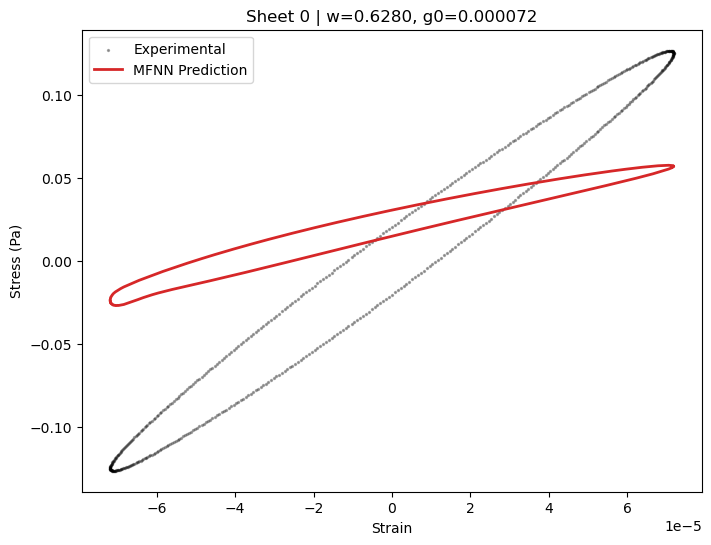

0.628rad - 0.0002555
Start Index:  0


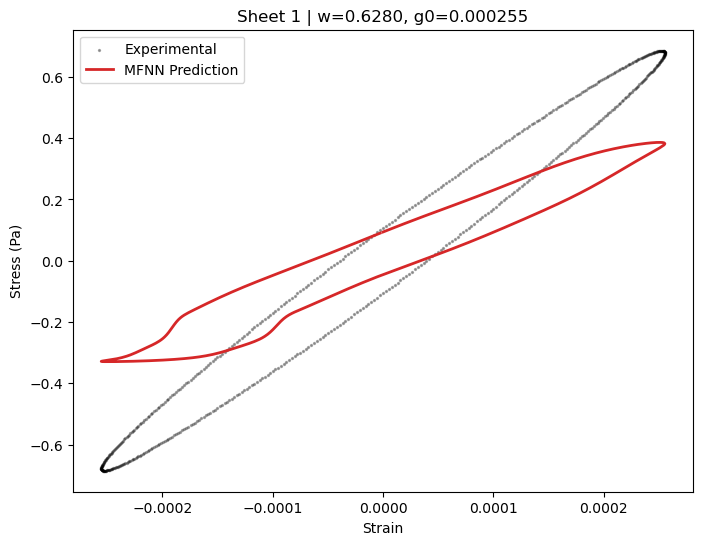

0.628rad - 0.0008726
Start Index:  0


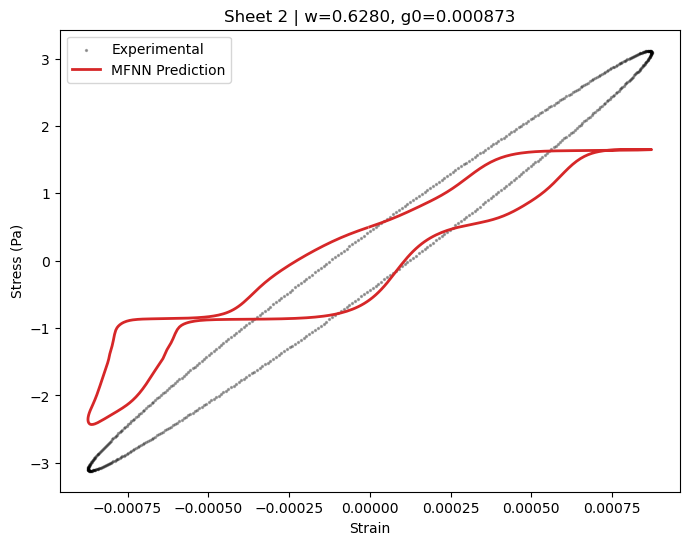

0.628rad - 0.0027413
Start Index:  0


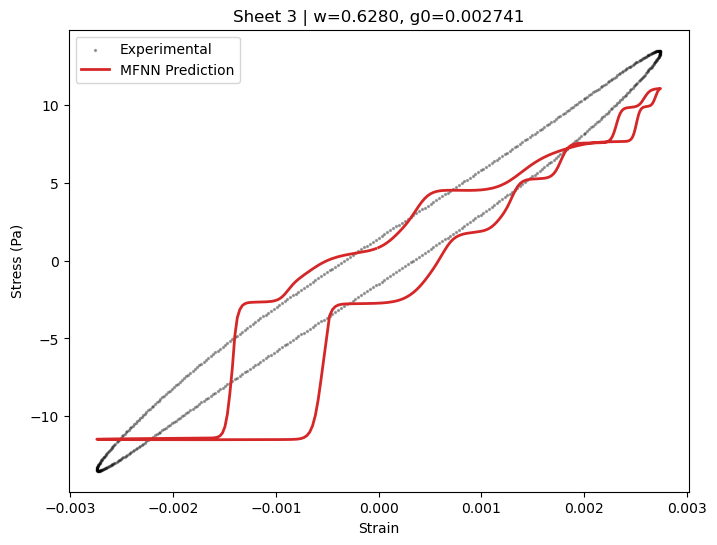

0.628rad - 0.0073965
Start Index:  0


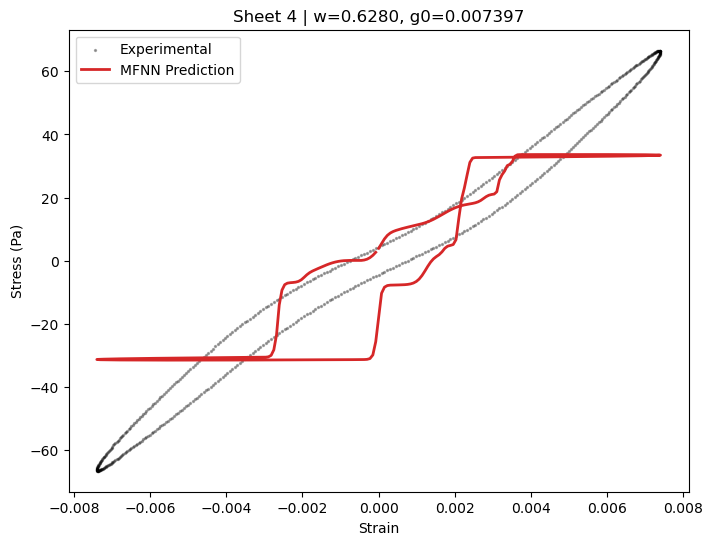

0.628rad - 0.0235937
Start Index:  0


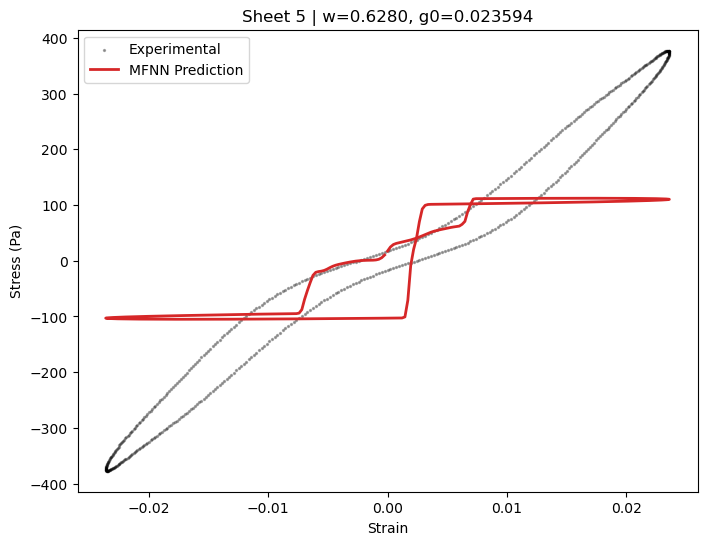

0.628rad - 7.46e-05
Start Index:  0


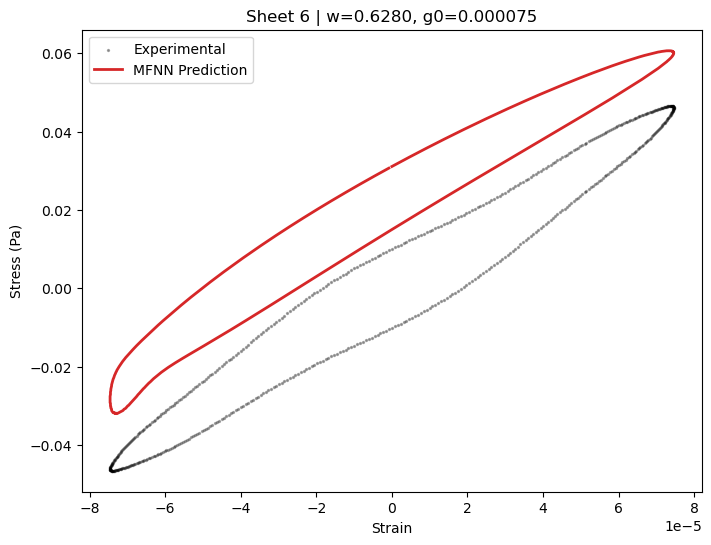

0.628rad - 0.0002212
Start Index:  0


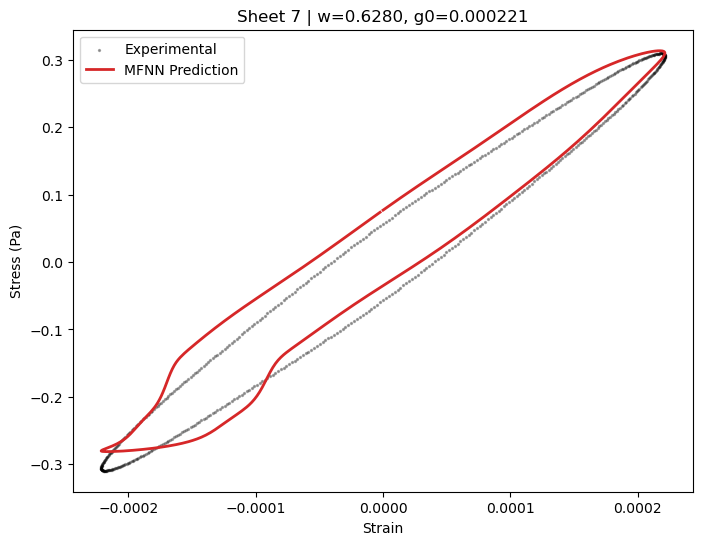

0.628rad - 0.0007927
Start Index:  0


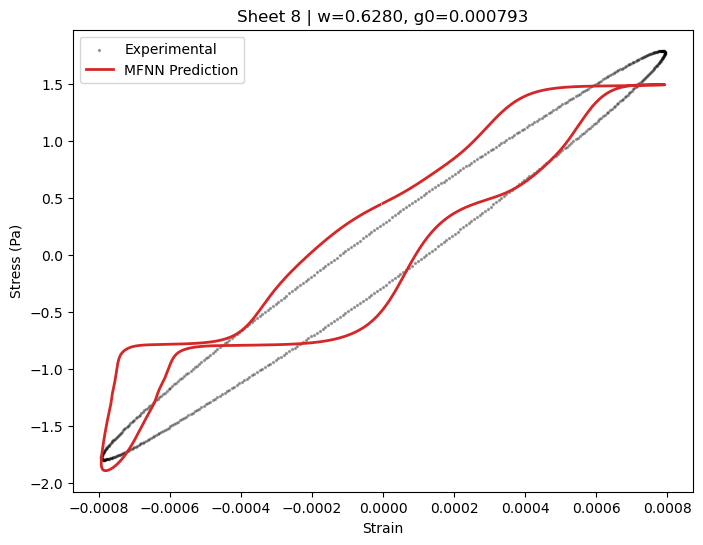

0.628rad - 0.0026243
Start Index:  0


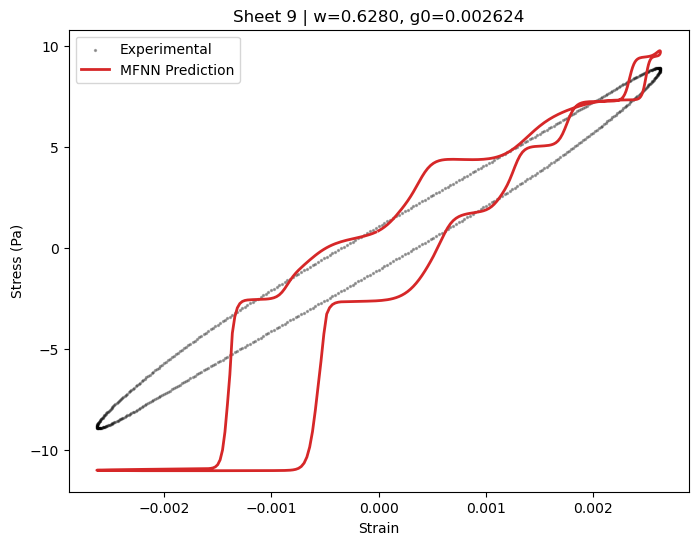

0.628rad - 0.0072428
Start Index:  0


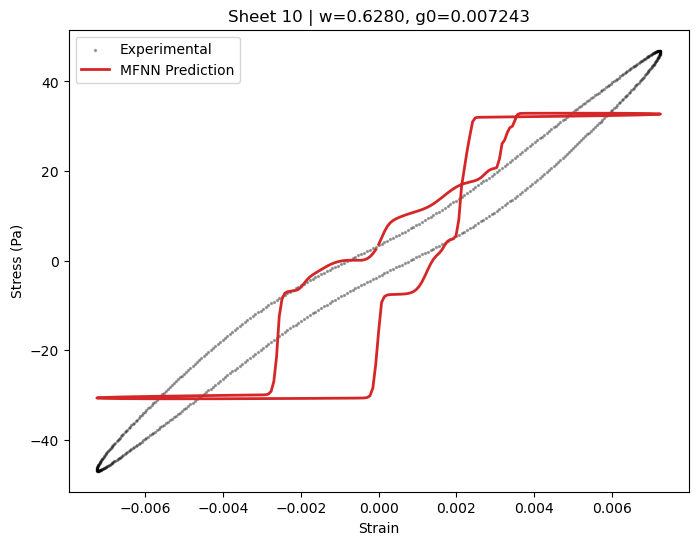

0.628rad - 0.036871
Start Index:  0


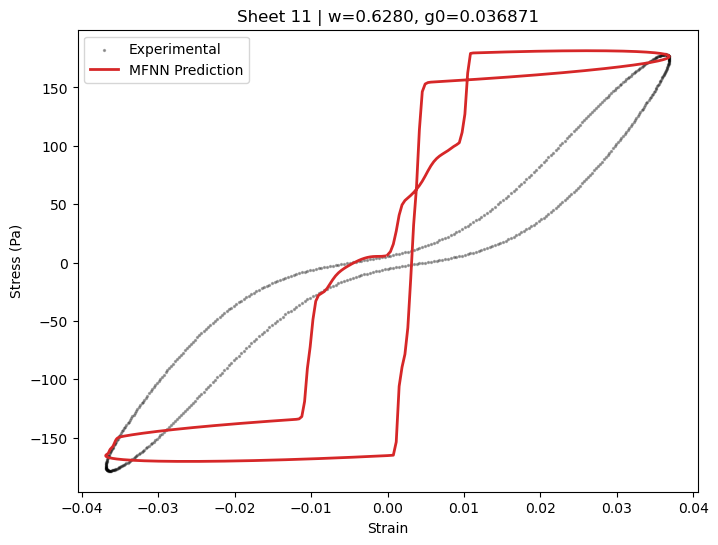

0.628rad - 7.76e-05
Start Index:  0


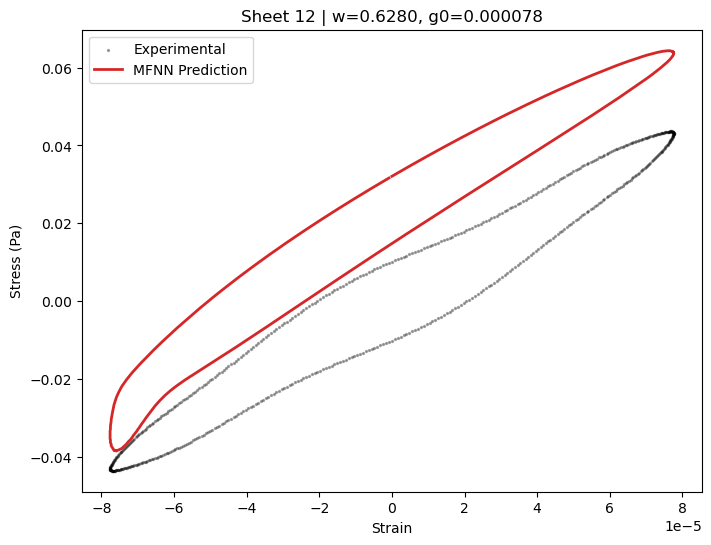

0.628rad - 0.000234
Start Index:  0


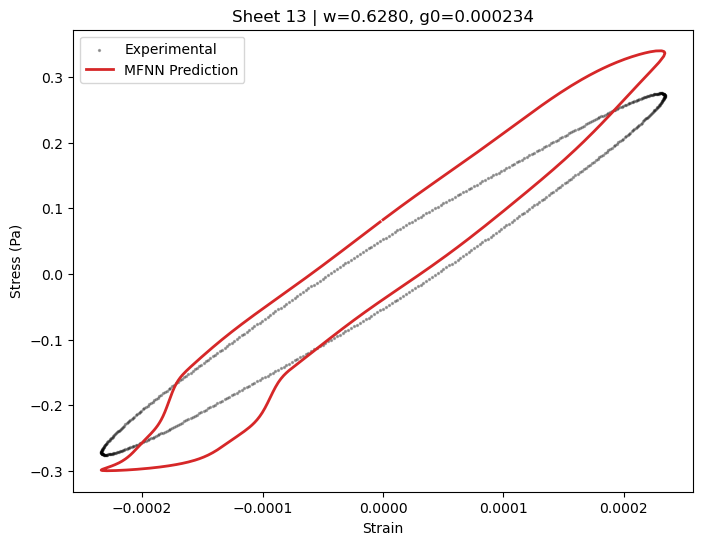

0.628rad - 0.0008087
Start Index:  0


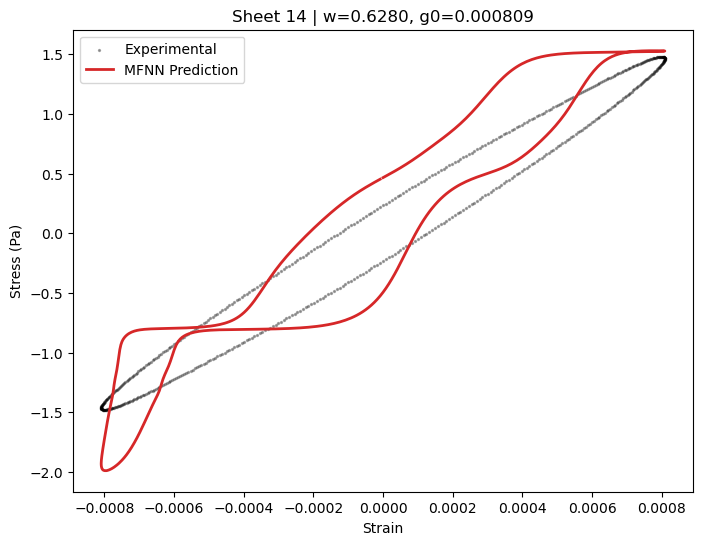

0.628rad - 0.002616
Start Index:  0


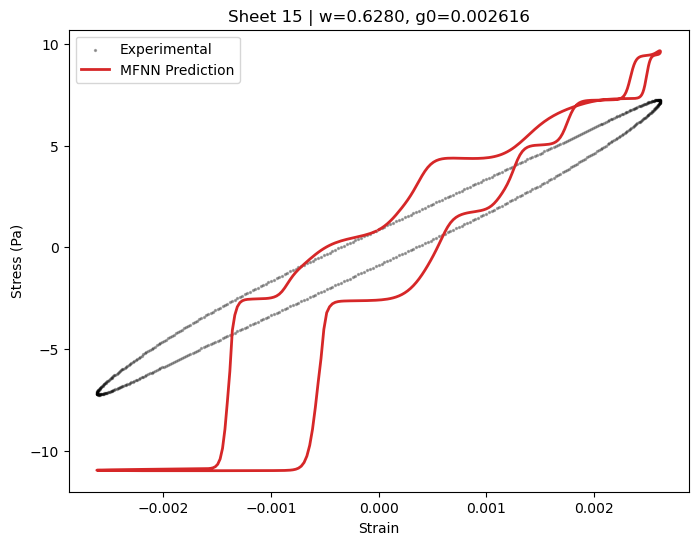

0.628rad - 0.0069447
Start Index:  0


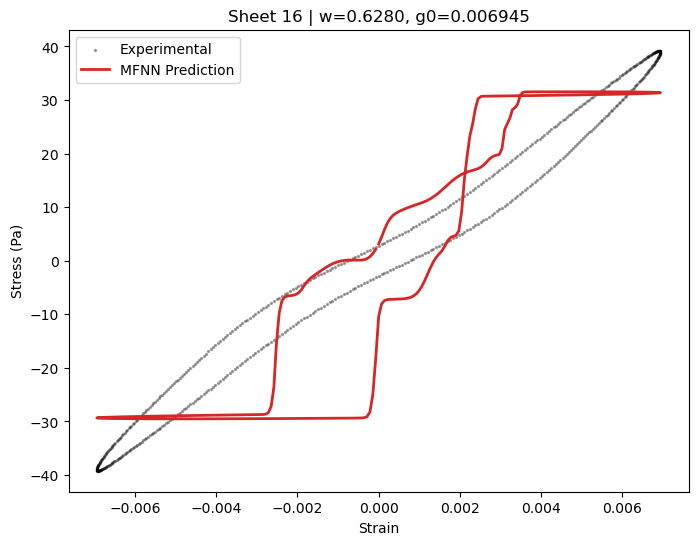

0.628rad - 0.0303729
Start Index:  0


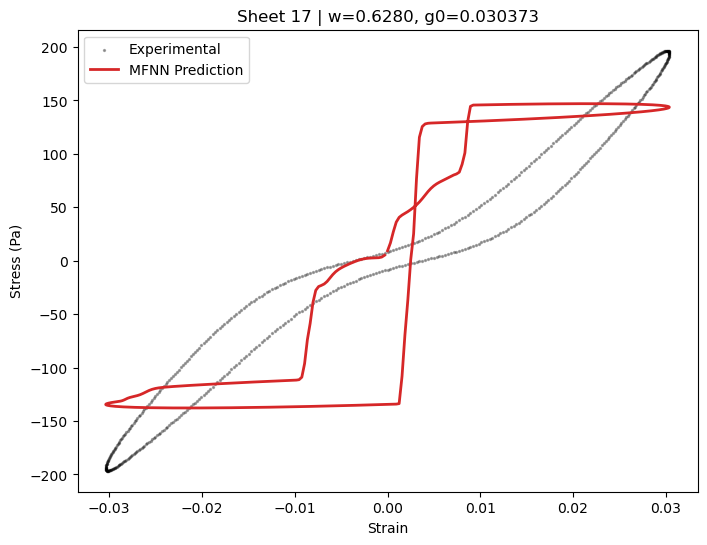

0.628rad - 6.77e-05
Start Index:  0


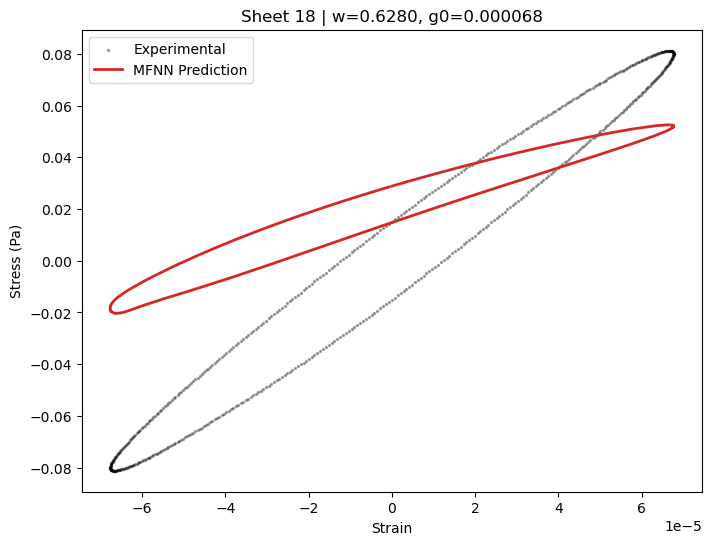

0.628rad - 0.0002321
Start Index:  0


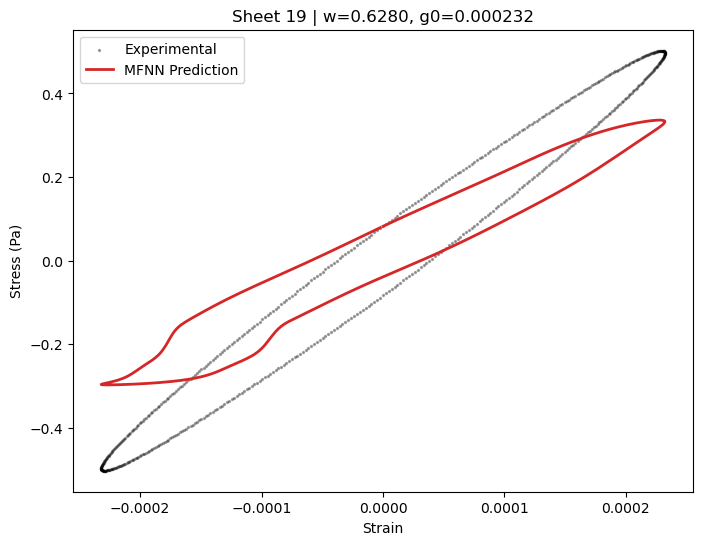

0.628rad - 0.000835
Start Index:  0


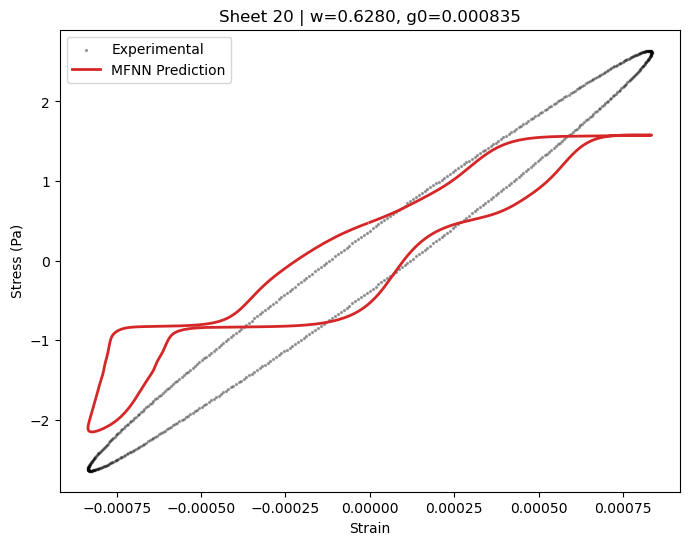

0.628rad - 0.0027183
Start Index:  0


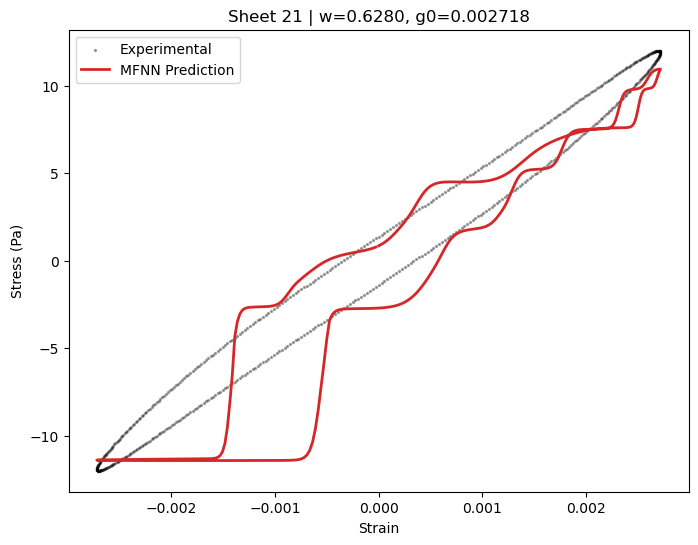

0.628rad - 0.0079461
Start Index:  0


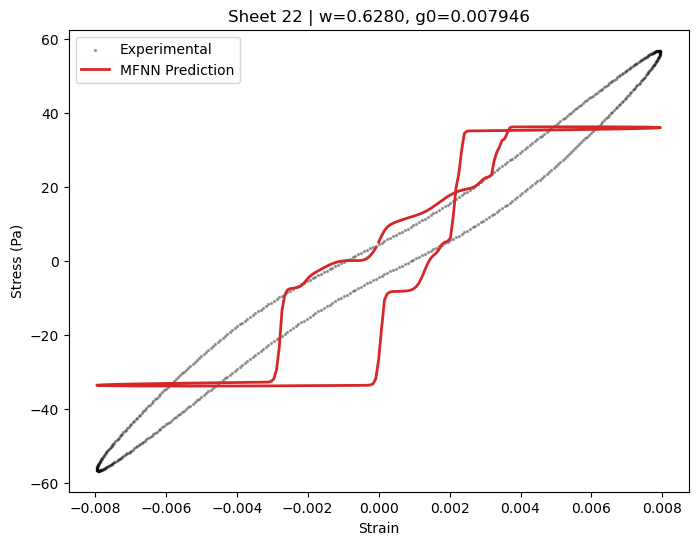

0.628rad - 7.83e-05
Start Index:  0


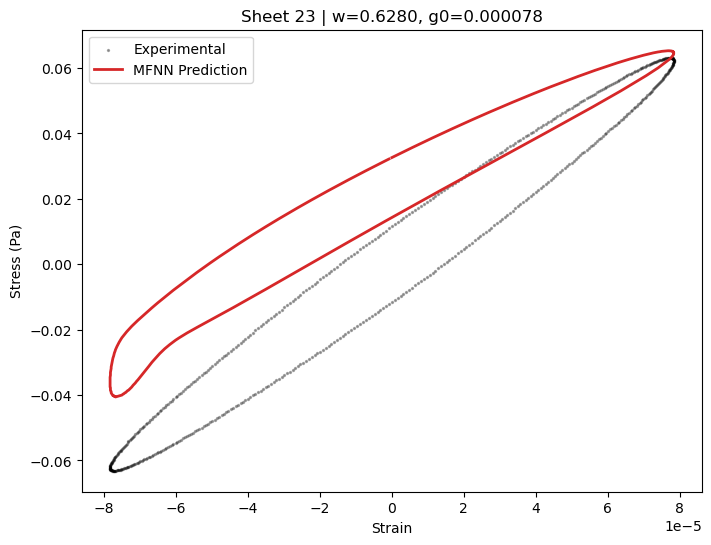

0.628rad - 0.0002521
Start Index:  0


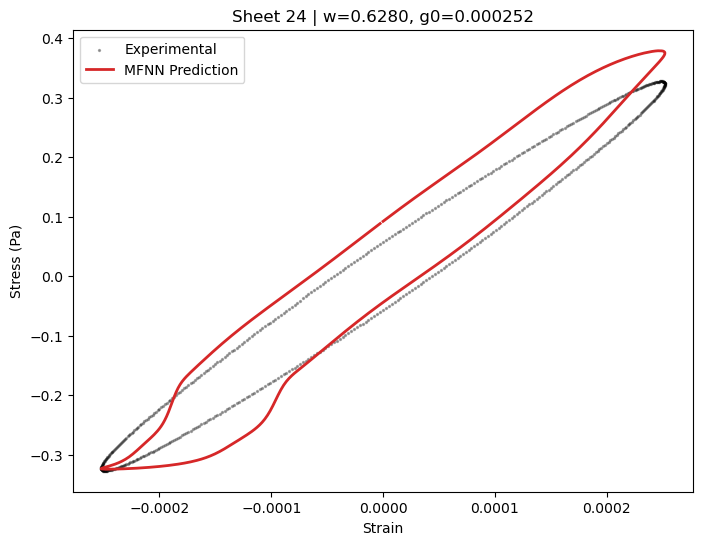

0.628rad - 0.0008682
Start Index:  0


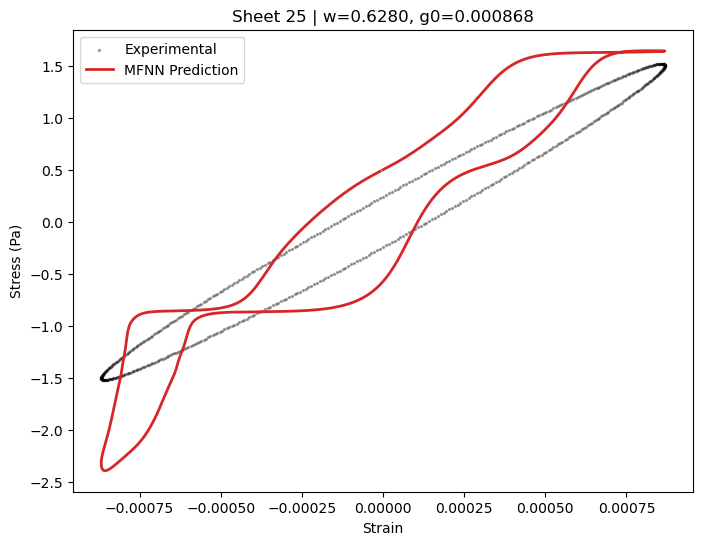

0.628rad - 0.0027884
Start Index:  0


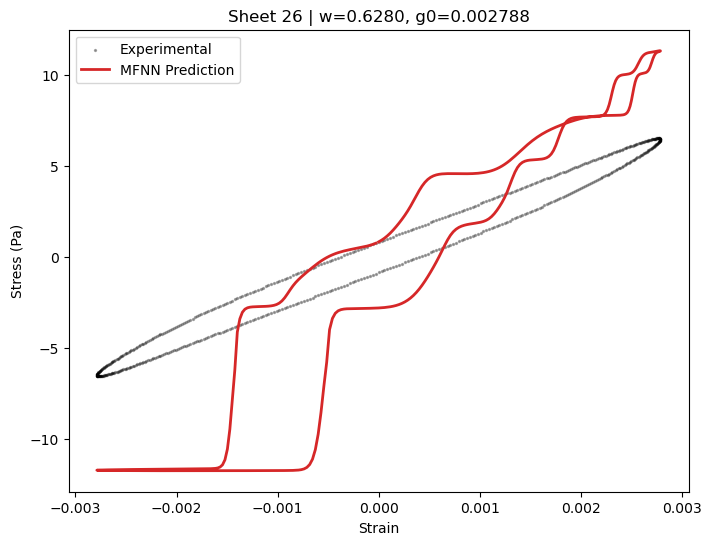

0.628rad - 0.0075938
Start Index:  0


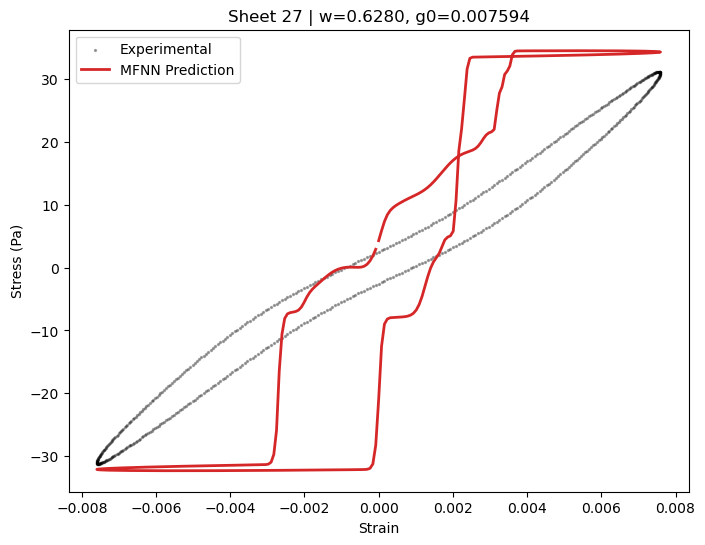

0.628rad - 0.041893
Start Index:  0


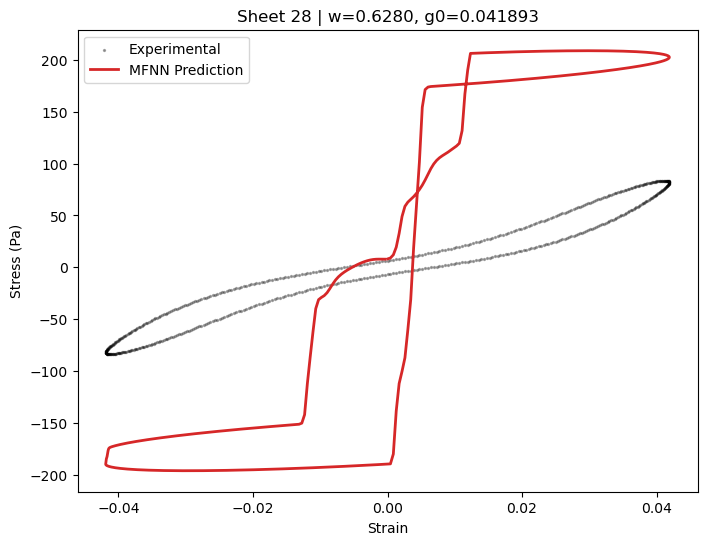

In [20]:
# --- FIXED VISUALIZATION ---
now = datetime.now().strftime("%Y_%m_%d-%H_%M_%S")

with pd.ExcelWriter(now+".xlsx") as writer:
    for i in range(len(data)):
        try:
            t_test, g0_test, w_test, s_test, st_test, sr_test = extractor(i)
            
            # Get Scalars
            g0 = np.unique(g0_test)[0]
            omega = np.unique(w_test)[0]

            # 1. Stack inputs including G0
            X_test_numpy = np.column_stack([st_test, sr_test, w_test, g0_test])
            
            # 2. Normalize inputs using the NEW scaler
            # Convert to Tensor first because scaler expects tensors
            X_test_tensor = tf.convert_to_tensor(X_test_numpy, dtype=DTYPE)
            X_test_norm = scaler.transform_x(X_test_tensor)
            
            # 3. Predict Shape (Reduced Stress)
            y_LF = model_LF(X_test_norm)
            X_MF = np.column_stack((X_test_norm, y_LF))
            y_MF = model_HF_nl(X_MF) + model_HF_l(X_MF)
            
            # 4. Denormalize: Physical Stress = Shape * G0
            # Note: y_MF is (N,1) tensor, g0 is scalar float
            y_MF_denorm = y_MF.numpy() * g0 
            
            # --- PLOTTING ---
            fig, ax = plt.subplots(figsize=(8, 6))
            ax.scatter(st_test, s_test, label='Experimental', color='k', s=2, alpha=0.3)
            ax.plot(st_test, y_MF_denorm, label='MFNN Prediction', color='tab:red', zorder=10, lw=2)
            plt.xlabel('Strain')
            plt.ylabel('Stress (Pa)')
            plt.title(f"Sheet {i} | w={omega:.4f}, g0={g0:.6f}")
            plt.legend()
            plt.show()
            
            # --- SAVING ---
            df_exp = np.column_stack([t_test, g0_test, w_test, st_test, sr_test, s_test, y_MF_denorm])
            df_exp = pd.DataFrame(df_exp)
            df_exp.columns = ['Time', 'G0', 'AngFreq', 'Strain', 'StrainRate', 'Stress', 'Stress_pred']
            safe_sheet_name = str(i)[:31]
            df_exp.to_excel(writer, sheet_name=safe_sheet_name, index=False)
            
        except Exception as e:
            print(f"Skipping sheet index {i} due to error: {e}")

In [ ]:
import shutil

# Choose director
save_dir = r"/home/alanh/projects/PunLab/mfnn/models"

# Save the three sub-models
model_LF.save(os.path.join(save_dir, 'model_LF'))
model_HF_nl.save(os.path.join(save_dir, 'model_HF_nl'))
model_HF_l.save(os.path.join(save_dir, 'model_HF_l'))

#Save the Normalization Vector
np.save(os.path.join(save_dir, 'normalization_vec.npy'), norm)

print(f"Models and normalization vector successfully saved to: {save_dir}")

In [ ]:
# Plot at w = 0.628rad, g0 = 0.0235937
t_test, g0_test, w_test, s_test, st_test, sr_test = extractor(5)
g0 = np.unique(g0_test)[0]
omega = np.unique(w_test)[0]

# 1. Stack inputs including G0
X_test = np.column_stack([st_test, sr_test, w_test, g0_test])
y_test = np.column_stack([s_test])

# 2. Normalize 
X_test_norm, y_test_norm = normalize_data(X_test, y_test, norm)

# 3. Predict
y_LF = model_LF(X_test_norm)
X_MF = np.column_stack((X_test_norm, y_LF))
y_MF = model_HF_nl(X_MF) + model_HF_l(X_MF)

# 4. Denormalize 
y_MF_denorm = y_MF * norm[-1]

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(st_test, y_MF_denorm, label='mf', color='tab:red', zorder=10, lw=2)
plt.xlabel('Strain')
plt.ylabel('Stress')
plt.title(f"Sheet {i} | w={omega:.6f}, g0={g0:.6f}")
plt.legend()

print(list(y_MF_denorm))

In [ ]:
# Plot without using experimental st_test and sr_test!

test_amps = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.03]

for i in test_amps:

    t_test, g0_test, w_test, s_test, st_test, sr_test = extractor(5)

    g0_test = g0_test / g0_test * i

    st_test = g0_test * np.sin(w_test * t_test)
    sr_test = g0_test * w_test * np.cos(w_test * t_test) * 100  # TODO: SHEAR RATE COLUMN IN WRONG UNITS

    g0 = np.unique(g0_test)[0]
    omega = np.unique(w_test)[0]

    # 1. Stack inputs including G0
    X_test = np.column_stack([st_test, sr_test, w_test, g0_test])
    y_test = np.column_stack([s_test])

    # 2. Normalize 
    X_test_norm, y_test_norm = normalize_data(X_test, y_test, norm)

    # 3. Predict
    y_LF = model_LF(X_test_norm)
    X_MF = np.column_stack((X_test_norm, y_LF))
    y_MF = model_HF_nl(X_MF) + model_HF_l(X_MF)

    # 4. Denormalize 
    y_MF_denorm = y_MF * norm[-1]

    # --- PLOTTING ---
    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(st_test, y_MF_denorm, label='mf', color='tab:red', zorder=10, lw=2)
    plt.xlabel('Strain')
    plt.ylabel('Stress')
    plt.title(f"Sheet {i} | w={omega:.6f}, g0={g0:.6f}")
    plt.legend()



In [ ]:
# Plot at w = 0.628rad, g0 = 0.0235937
t_test, g0_test, w_test, s_test, st_test, sr_test = extractor(5)
g0 = np.unique(g0_test)[0]
omega = np.unique(w_test)[0]

# 1. Stack inputs including G0
X_test = np.column_stack([st_test, sr_test, w_test, g0_test])
y_test = np.column_stack([s_test])

# 2. Normalize 
X_test_norm, y_test_norm = normalize_data(X_test, y_test, norm)

# 3. Predict
y_LF = model_LF(X_test_norm)
X_MF = np.column_stack((X_test_norm, y_LF))
y_MF = model_HF_nl(X_MF) + model_HF_l(X_MF)

# 4. Denormalize 
y_MF_denorm = y_MF * norm[-1]

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(st_test, y_MF_denorm, label='mf', color='tab:red', zorder=10, lw=2)
plt.xlabel('Strain')
plt.ylabel('Stress')
plt.title(f"Sheet {i} | w={omega:.6f}, g0={g0:.6f}")
plt.legend()

print(list(y_MF_denorm))

In [ ]:
# Plot at w = 0.628rad, g0 = 0.0235937
t_test, g0_test, w_test, s_test, st_test, sr_test = extractor(5)
g0 = np.unique(g0_test)[0]
omega = np.unique(w_test)[0]

# 1. Stack inputs including G0
X_test = np.column_stack([st_test, sr_test, w_test, g0_test])
y_test = np.column_stack([s_test])

# 2. Normalize 
X_test_norm, y_test_norm = normalize_data(X_test, y_test, norm)

# 3. Predict
y_LF = model_LF(X_test_norm)
X_MF = np.column_stack((X_test_norm, y_LF))
y_MF = model_HF_nl(X_MF) + model_HF_l(X_MF)

# 4. Denormalize 
y_MF_denorm = y_MF * norm[-1]

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(st_test, y_MF_denorm, label='mf', color='tab:red', zorder=10, lw=2)
plt.xlabel('Strain')
plt.ylabel('Stress')
plt.title(f"Sheet {i} | w={omega:.6f}, g0={g0:.6f}")
plt.legend()

print(list(y_MF_denorm))

In [ ]:
# Plot at w = 0.628rad, g0 = 0.023593 using CALCULATED inputs

# 1. Extract the raw data containers first
t_test, g0_test, w_test, s_test, st_test_exp, sr_test_exp = extractor(5)

# 2. Get scalar values for the equation
g0 = np.max(g0_test) 
omega = np.max(w_test)

print(f"Calculating with G0: {g0} and w: {omega}")

# 3. Calculate analytical Strain and Rate
# We use t_test (which is Time_adj) from the extractor
st_test_calc = g0 * np.sin(omega * t_test)
sr_test_calc = g0 * omega * np.cos(omega * t_test) * 100 / omega # TODO: FIX THIS IN DATA

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(t_test[:100], st_test_exp[:100], 'k-', label='Experimental', alpha=0.5)
plt.plot(t_test[:100], st_test_calc[:100], 'r--', label='Calculated')
plt.title('Strain Comparison (First 100 pts)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(t_test[:100], sr_test_exp[:100], 'k-', label='Experimental', alpha=0.5)
plt.plot(t_test[:100], sr_test_calc[:100], 'r--', label='Calculated')
plt.title('Rate Comparison (First 100 pts)')
plt.legend()
plt.show()

w_vec = np.full_like(st_test_calc, omega)
g0_vec = np.full_like(st_test_calc, g0)

X_test = np.column_stack([st_test_calc, sr_test_calc, w_vec, g0_vec])
y_test = np.column_stack([s_test]) # Ground truth stress

# Normalize 
X_test_norm, y_test_norm = normalize_data(X_test, y_test, norm)

# Predict
y_LF = model_LF(X_test_norm)
X_MF = np.column_stack((X_test_norm, y_LF))
y_MF = model_HF_nl(X_MF) + model_HF_l(X_MF)

# Denormalize 
y_MF_denorm = y_MF * norm[-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(st_test_calc, y_MF_denorm, label='MFNN (Calc Input)', color='tab:red', zorder=10, lw=2)
ax.plot(st_test_exp, s_test, label='Experimental Truth', color='k', alpha=0.2)

plt.xlabel('Strain')
plt.ylabel('Stress')
plt.title(f"Sheet 5 | w={omega:.4f}, g0={g0:.4f}")
plt.legend()
plt.show()